# Data Pipeline Part 2 : Feast-backed data pipeline 

In this hands-on, we’ll simulate a compact end-to-end feature pipeline using Pandas, NumPy, Scikit-learn, and Feast.

Objectives:

Stand up a minimal Feast repo (offline file store + online SQLite).
Prepare and register a simple entity, data sources, and a FeatureView.
Retrieve historical features to create a train/validation set safely (no leakage).
Train & evaluate a model using scikit-learn metrics (F1, ROC AUC, classification report).
Materialize to online and do a small feature lookup (serving-style query).

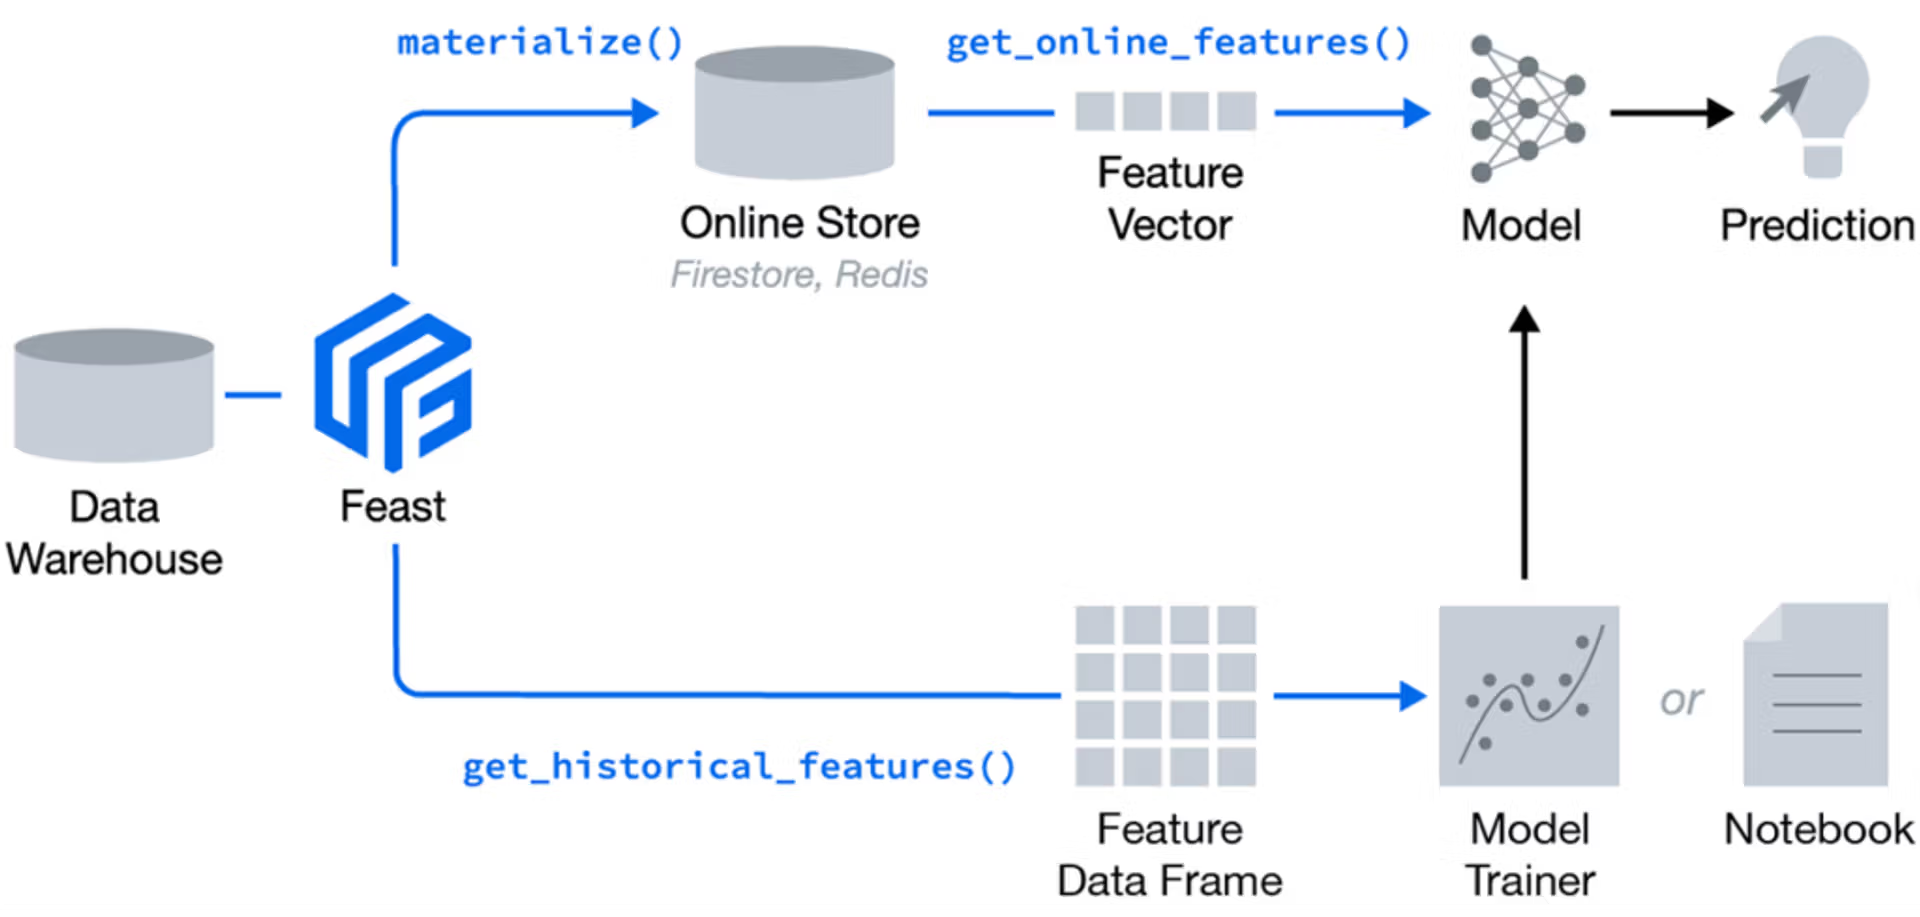

In [25]:
# ── Standard library ─────────────────────────────────────────────────────────
import shutil, warnings
# shutil   → wipes the Feast repo directory between runs (ensures a clean slate)
# warnings → suppresses DeprecationWarnings from Feast internals to keep output readable

import numpy as np                          # random timestamp generation for simulation
import pandas as pd                         # dataframe operations throughout the pipeline
from pathlib import Path                    # cross-platform, OS-agnostic file paths
from datetime import datetime, timezone, timedelta  # UTC-aware timestamp arithmetic

# ── Feast: Feature Store ──────────────────────────────────────────────────────
from feast import FeatureStore, Entity, Field, FileSource, FeatureView, FeatureService
# FeatureStore    → main entry point; reads feature_store.yaml and runs all operations
# Entity          → the 'who' your features describe — the join key (e.g. customer_id)
# Field           → a single typed column declaration inside a FeatureView schema
# FileSource      → tells Feast where the parquet feature data lives on disk
# FeatureView     → core Feast unit: binds entity + source + schema + TTL
# FeatureService  → a named bundle of features for a specific model/endpoint
from feast.types import Int64, Float32      # Feast-native types used in schema declarations
from feast.value_type import ValueType      # used when declaring the entity key type

# ── Scikit-learn: Model Training ──────────────────────────────────────────────
from sklearn.metrics import classification_report, roc_auc_score, f1_score
# classification_report → per-class precision/recall/F1
# roc_auc_score         → threshold-independent ranking quality metric
# f1_score              → used during threshold tuning on the validation set

from sklearn.preprocessing import LabelEncoder
# LabelEncoder → maps strings to integers (e.g. 'Yes'→1, 'No'→0)
# Used ONLY to satisfy Feast's numeric storage requirement, NOT for the actual model

from sklearn.linear_model import LogisticRegression   # baseline linear classifier
from sklearn.compose import ColumnTransformer         # apply different transforms per column group
from sklearn.pipeline import Pipeline                 # chain preprocessing + model as one object
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# OneHotEncoder  → expands categoricals into binary dummy columns (used in model pipeline)
# StandardScaler → zero-mean, unit-variance scaling required for logistic regression

from sklearn.impute import SimpleImputer  # fills NaN before feeding data to the model

warnings.filterwarnings('ignore', category=DeprecationWarning)  # silence Feast deprecation noise


# Repoistory & Configuration boostrap 

- Wipe any previous repo and create a frash one 
- Config with : 
     - offline file store type : file 
     - online store : sqlite for serving 
     - registry file to track the applied objects 
     
![alt text](image.png)

In [26]:
# ── STEP 1: Bootstrap the Feast Repository ───────────────────────────────────
# A Feast 'repo' is a directory containing:
#   feature_store.yaml → backend config (which offline/online store + registry location)
#   data/              → where parquet feature files are written and read by Feast
#   registry.db        → auto-created by store.apply(); stores entity/view/service metadata
#   online_store.db    → auto-created by materialize(); holds latest feature values for serving

from pathlib import Path
import shutil

REPO_DIR = Path('feat_telco_repo')

# Wipe the directory if it exists from a previous run
# Stale registry entries would conflict with freshly declared objects otherwise
if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)

# Create the data/ subdirectory now so parquet files can be written into it later
(REPO_DIR / 'data').mkdir(parents=True, exist_ok=True)

# Write feature_store.yaml — the single config file Feast reads on startup
yaml_content = (
    'project: telco_churn\n'                          # logical namespace for this store
    'registry: "registry.db"\n'                       # SQLite file tracking all registered objects
    'provider: local\n'                               # run locally; prod options: gcp / aws
    'offline_store:\n'
    '  type: file\n'                                  # read from local parquet; prod: bigquery/redshift
    'online_store:\n'
    '  type: sqlite\n'                                # key-value store for serving; prod: redis/dynamodb
    '  path: "online_store.db"\n'
    'entity_key_serialization_version: 3\n'           # internal Feast protocol version — keep as 3
)
(REPO_DIR / 'feature_store.yaml').write_text(yaml_content)


556

In [27]:
# Inspect the raw dataframe before any cleaning
# Things to notice: 'customerID' (will be renamed), 'TotalCharges' (string not float),
# 'Churn' column is 'Yes'/'No' string — needs to become a binary integer label
df.head(5)


,customer_id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,label,feature_ts,label_ts,created_at
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,2025-12-24 01:49:57.213073+00:00,2026-01-23 01:49:57.213073+00:00,2025-12-24 01:54:57.213073+00:00
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,0,2026-03-03 05:12:51.213073+00:00,2026-04-02 05:12:51.213073+00:00,2026-03-03 05:17:51.213073+00:00
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,2026-02-04 23:17:59.213073+00:00,2026-03-06 23:17:59.213073+00:00,2026-02-04 23:22:59.213073+00:00
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,2026-01-19 23:17:37.213073+00:00,2026-02-18 23:17:37.213073+00:00,2026-01-19 23:22:37.213073+00:00
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,2025-11-27 20:29:27.213073+00:00,2025-12-27 20:29:27.213073+00:00,2025-11-27 20:34:27.213073+00:00


# Data sources and feature defintions

In [28]:
# ── STEP 2: Load the Raw Dataset ─────────────────────────────────────────────
# Telco Customer Churn — public binary classification dataset
#   ~7,043 rows | 21 columns | Target: 'Churn' (Yes/No)
#   Features: demographics, contract type, services subscribed, billing amounts

import pandas as pd

URL = 'https://raw.githubusercontent.com/aiplanethub/Datasets/master/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(URL)  # raw load — no transformations yet

df.head()  # spot-check: TotalCharges is a string (blank spaces for new customers), Churn is Yes/No


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [29]:
# ── STEP 3: Clean and Prepare the Dataset ────────────────────────────────────

# Rename customerID → customer_id (must match the Feast Entity join_key declared later)
# .copy() creates a clean DataFrame copy to avoid pandas SettingWithCopyWarning
df = df.rename(columns={'customerID': 'customer_id'}).copy()

# TotalCharges contains blank strings for ~11 customers with tenure=0
# errors='coerce' converts unparseable strings to NaN instead of raising an exception
df['TotalCharges']   = pd.to_numeric(df['TotalCharges'],   errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df['tenure']         = pd.to_numeric(df['tenure'],         errors='coerce')

# Drop rows missing any critical column
# We cannot impute the label (Churn) or entity key (customer_id) — both must be present
df = df.dropna(subset=['customer_id', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'])

# Encode the target as a binary integer
# Chain: astype(str) → strip whitespace → lowercase → compare 'yes' → bool → int
# Result: 'Yes' → 1 (churned), 'No' → 0 (retained)
df['label'] = (
    df['Churn']
    .astype(str)   # guard against any non-string remnants
    .str.strip()   # remove accidental leading/trailing spaces
    .str.lower()   # normalize: 'Yes', 'YES', 'yes' all become 'yes'
    == 'yes'       # boolean comparison → True/False Series
).astype(int)      # True→1, False→0


In [ ]:
# Verify cleaning worked:
#  ✓ 'customer_id' column exists (renamed from customerID)
#  ✓ TotalCharges / MonthlyCharges / tenure are numeric (no strings)
#  ✓ 'label' column is 0 or 1 integer
#  ✓ row count is reasonable (~7,032 after dropping NaN rows)
df.head()

,customer_id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,label
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## Timestamp Engineering — Prediction Horizon & Leakage Prevention

Before we feed data into Feast, we need **three timestamps** per row. Here is why:

---

### The Core Idea

In real churn prediction, you observe a customer today but only find out if they churned **later**.
The gap between observation and outcome is the **prediction horizon**.



---

### Why the Gap Matters — Data Leakage

Without a horizon, you risk including features that were **updated after the churn event** — data your model could never have in production:



---

### The Three Columns We Create

| Column | Meaning | Used by |
|---|---|---|
|  | When the feature was observed | Feast (source timestamp) |
|  | When the outcome is known () | Feast point-in-time join |
|  | When the row was ingested () | Feast dedup logic |

> **Note:** This dataset is a static CSV with no real timestamps. We simulate them here so Feast can enforce the time boundary. In production, your data warehouse already has real event timestamps — you skip this step.


In [31]:
# ── STEP 4: Simulate Event Timestamps ────────────────────────────────────────
# Feast is time-aware: every stored feature value must carry an event_timestamp.
# This dataset is a static CSV with no real timestamps, so we simulate them.
# In production your data warehouse already has real timestamps — this block is skipped.

HORIZON_DAYS = 30  # prediction gap: churn outcome is observed 30 days after feature observation

# Outer boundaries of the simulated time window
rng_end   = datetime.now(timezone.utc)        # latest point = 'now'
rng_start = rng_end - timedelta(days=150)     # 150 days back = earliest feature observation

# Feature timestamps must NOT fall inside the last 30 days (the label horizon window)
# because at real prediction time those future values would not yet exist — that is leakage.
# Safe feature zone: [rng_start  →  rng_end - 30 days]
feat_span_sec = (rng_end - timedelta(days=HORIZON_DAYS) - rng_start).total_seconds()

np.random.seed(42)  # fix seed → reproducible timestamps and consistent train/val/test splits

# Assign each customer a random feature observation time within the safe zone
df['feature_ts'] = [
    rng_start + timedelta(seconds=int(np.random.rand() * feat_span_sec))
    for _ in range(len(df))
]

# label_ts = feature_ts + 30 days → the moment we know whether the customer churned
# This becomes the event_timestamp in entity_labels.parquet
# Feast uses it as the join anchor: only features at or before this moment are returned
df['label_ts'] = df['feature_ts'] + timedelta(days=HORIZON_DAYS)

# created_at = ingestion timestamp (slightly after feature_ts)
# Feast uses this to break ties when multiple records exist for the same event_timestamp
# (e.g. late-arriving data — Feast picks the most recently ingested row)
df['created_at'] = df['feature_ts'] + timedelta(minutes=5)


In [32]:
# ── STEP 5: Declare Feature Column Groups ────────────────────────────────────
# Separating numerics and categoricals serves two purposes:
#   1. Feast schema  → Float32 for continuous, Int64 for label-encoded categoricals
#   2. sklearn pipeline → StandardScaler on numerics, OneHotEncoder on categoricals

categorical_features = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'
]

numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# all_features = the exact ordered list passed to Feast schema and the model
# Order matters: ColumnTransformer references columns by name, but consistency prevents bugs
all_features = numerical_features + categorical_features


# Label encoding for Feast

Feast can't handle raw strings , so we need to create an encoded copy for the storage and keep the original for training later.(this encoding is not used for the model , the model use OneHotEncoding after splitting)

In [33]:
# ── STEP 6: Encode Categoricals for Feast Storage ────────────────────────────
# Feast's local file store (parquet + SQLite) only handles numeric types cleanly.
# We create a separate encoded copy (df_feast) and keep the original df with raw strings
# for the sklearn pipeline which does its own, better-suited OneHotEncoding.
#
# LabelEncoder maps each unique string to a stable integer:
#   Contract: 'Month-to-month'→0, 'One year'→1, 'Two year'→2
#   gender:   'Female'→0, 'Male'→1
#
# These integers are ONLY for Feast storage — the model never directly uses them.
# The sklearn pipeline OneHotEncodes from the raw strings in the original df.

df_feast = df.copy()  # work on a copy — never modify df (raw strings needed by the model)

for col in categorical_features:
    le = LabelEncoder()
    # astype(str) ensures NaN values don't crash LabelEncoder
    df_feast[col] = le.fit_transform(df_feast[col].astype(str))


### Save Feature + Label Datasets

In [34]:
# ── STEP 7: Persist Feature and Label Data as Parquet ────────────────────────
# Feast reads from files — we write two separate parquet files:
#
#   telco_features.parquet  → feature values per customer at a point in time
#       columns: customer_id | all_features | event_timestamp | created_at
#       event_timestamp = feature_ts (when the feature was observed)
#
#   entity_labels.parquet   → entity IDs + labels + the join anchor timestamp
#       columns: customer_id | event_timestamp (= label_ts) | label
#       event_timestamp = label_ts (when the outcome is known)

features_path     = REPO_DIR / 'data' / 'telco_features.parquet'
entity_label_path = REPO_DIR / 'data' / 'entity_labels.parquet'

# Feature file: use df_feast (encoded integers) and rename feature_ts → event_timestamp
# 'event_timestamp' is the required column name that Feast looks for in the source file
df_feast[['customer_id', *all_features, 'feature_ts', 'created_at']].rename(
    columns={'feature_ts': 'event_timestamp'}
).to_parquet(features_path, index=False)

# Label file: use original df (keeps raw strings), rename label_ts → event_timestamp
# This event_timestamp is what we pass to get_historical_features() as the join anchor:
# 'give me features for this customer as they existed at this exact point in time'
df[['customer_id', 'label_ts', 'label']].rename(
    columns={'label_ts': 'event_timestamp'}
).to_parquet(entity_label_path, index=False)


### Define Feast Entity, Source, and FeatureView

In [35]:
# ── STEP 8: Define Feast Objects and Register Them ───────────────────────────

# Entity: declares the primary key of the feature store
# join_keys must match the column name in both the feature parquet AND the entity_df
customer = Entity(
    name='customer_id',
    join_keys=['customer_id'],
    value_type=ValueType.STRING,  # customer IDs are strings like '7590-VHVEG'
)

# FileSource: tells Feast where to find feature values and which column is the timestamp
# created_timestamp_column → used by Feast to resolve duplicates:
#   if two records share the same event_timestamp, the one with the latest created_at wins
source = FileSource(
    path='data/telco_features.parquet',   # relative to REPO_DIR
    timestamp_field='event_timestamp',     # column carrying the feature observation time
    created_timestamp_column='created_at', # ingestion time — deduplication tiebreaker
)

# Build the Feast schema dynamically from our feature lists
# Float32 for continuous numerics, Int64 for label-encoded categoricals
schema = [
    Field(name=col, dtype=(Float32 if col in numerical_features else Int64))
    for col in all_features
]

# FeatureView: the core Feast object — binds entity + source + schema + TTL together
# ttl=365 days → Feast accepts a feature value if it falls within 365 days before the join timestamp
#               if no record exists within the TTL window, Feast returns null for that row
# online=True  → this view can be materialized to the online store for real-time serving
customer_stats = FeatureView(
    name='customer_stats',
    entities=[customer],
    ttl=timedelta(days=365),
    schema=schema,
    source=source,
    online=True,
)

# Initialize FeatureStore pointing at the local repo directory (reads feature_store.yaml)
store = FeatureStore(repo_path=str(REPO_DIR))

# store.apply() registers all objects in registry.db
# This is metadata-only — no data is moved yet, only schemas and configs are stored
store.apply([customer, customer_stats])


### Retrieve Point-in-Time Correct Features

In [36]:
# ── STEP 9: Retrieve Point-in-Time Correct Features ──────────────────────────
# This is the most important step — it builds the leakage-safe training dataset.
#
# entity_df has: customer_id | event_timestamp (= label_ts) | label
# For each row, Feast finds the most recent feature record where:
#     feature event_timestamp  <=  entity event_timestamp   (no future data)
#     feature event_timestamp  >=  entity event_timestamp - TTL  (not too stale)
#
# This perfectly mirrors what the model sees in production:
# 'predict churn using only data that existed before the label observation date'

entity_df = pd.read_parquet(entity_label_path)

training_df = store.get_historical_features(
    entity_df=entity_df,
    # Reference features as 'feature_view_name:feature_name'
    features=[f'customer_stats:{f}' for f in all_features],
).to_df()  # execute the point-in-time join and return as a pandas DataFrame

# Drop rows where the join returned nulls
# This happens when a customer had no feature record within the TTL window
training_df = training_df.dropna(subset=all_features + ['label'])
training_df['label'] = training_df['label'].astype(int)  # ensure int type after join


### Time-Based Split (Leakage Safe)

In [37]:
# ── STEP 10: Time-Based Train / Validation / Test Split ──────────────────────
# Split by time, NOT random shuffle — critical for temporal data.
# A random split leaks future patterns into training, inflating metrics.
# Time-based split mirrors production: the model always predicts on data it has never seen.
#
# Split by timestamp quantile (70 / 15 / 15):
#   Train → earliest 70%  : model learns historical patterns
#   Val   → next 15%      : threshold tuning and model selection
#   Test  → latest 15%    : final unbiased evaluation, touched only once

ts = training_df['event_timestamp']
q_train = ts.quantile(0.70)  # time cutoff between train and val
q_val   = ts.quantile(0.85)  # time cutoff between val and test

train_df = training_df[ts <= q_train].copy()
val_df   = training_df[(ts > q_train) & (ts <= q_val)].copy()
test_df  = training_df[ts > q_val].copy()

# Separate features (X) from label (y) for each split
X_tr, y_tr = train_df[all_features], train_df['label']
X_va, y_va = val_df[all_features],   val_df['label']
X_te, y_te = test_df[all_features],  test_df['label']


### ML Preprocessing Pipeline

In [38]:
# ── STEP 11: Build the Preprocessing + Model Pipeline ────────────────────────
# A sklearn Pipeline chains all steps into one object.
# This guarantees identical transformations at training time and serving time.

# Numeric features: fill NaN with column mean → scale to zero-mean unit-variance
# StandardScaler is required: logistic regression is sensitive to feature magnitude
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  # handles any NaN from the Feast join
    ('scaler',  StandardScaler())
])

# Categorical features (label-encoded integers from Feast storage):
# fill NaN with most common value → expand to binary columns via one-hot encoding
# handle_unknown='ignore' → unseen categories at serving time become all-zero rows (no crash)
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer applies each sub-pipeline to its designated column group in parallel
# Output is a single concatenated numeric matrix passed to the classifier
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline,     numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Final pipeline: preprocessing → logistic regression classifier
# class_weight='balanced' corrects for class imbalance (~26% churn in dataset)
# max_iter=5000 ensures convergence after the one-hot expansion enlarges the feature space
pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=5000, class_weight='balanced'))
])


In [ ]:
# ── STEP 12: Train the Pipeline ──────────────────────────────────────────────
# Internally: fit preprocessor on X_tr → transform X_tr → fit LogisticRegression
# After this, the pipeline holds the fitted scaler, encoder categories, and model weights
pipeline.fit(X_tr, y_tr)

,steps,"[('pre', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [40]:
# ── STEP 13: Tune the Classification Threshold on Validation Set ─────────────
# Default predict() uses threshold=0.5, but this is rarely optimal for imbalanced data.
# We sweep 201 thresholds [0.0 → 1.0] and pick the one that maximises F1 on validation.
#
# Why F1? It balances precision and recall:
#   - False positives (non-churner flagged) → wasted retention offer (business cost)
#   - False negatives (churner missed)      → lost customer (business cost)
#   F1 penalises both equally
#
# Rule: tune threshold on VALIDATION set only — never look at test set during tuning

y_prob_va = pipeline.predict_proba(X_va)[:, 1]  # churn probability for each validation row

thresholds = np.linspace(0.0, 1.0, 201)  # 201 candidate thresholds
best_t, best_f1 = 0.5, -1.0              # initialise with default threshold

for t in thresholds:
    preds = (y_prob_va >= t).astype(int)          # classify as churn if prob >= threshold
    f1    = f1_score(y_va, preds, zero_division=0)  # zero_division=0 → returns 0 if no positive preds
    if f1 > best_f1:
        best_t, best_f1 = t, f1  # keep best threshold found so far


In [41]:
# ── STEP 14: Final Evaluation on Held-Out Test Set ───────────────────────────
# Apply the threshold chosen on validation to the test set (model has never seen this data).
#
# ROC AUC  → threshold-independent; measures ability to rank churners above non-churners
#             0.5 = random, 1.0 = perfect
# F1/Precision/Recall → at the chosen threshold; gives the operational performance picture

y_prob_te = pipeline.predict_proba(X_te)[:, 1]  # churn probabilities for test rows
y_pred_te = (y_prob_te >= best_t).astype(int)   # apply the val-tuned threshold

print(f'\nChosen threshold (from val): {best_t:.2f}')
print(f'Test ROC AUC:   {roc_auc_score(y_te, y_prob_te):.4f}')
print('\n=== Test Classification Report ===')
print(classification_report(y_te, y_pred_te, digits=4))
# digits=4 → four decimal places for precise comparison across experiments



Chosen threshold (from val): 0.57
Test ROC AUC:   0.8293

=== Test Classification Report ===
              precision    recall  f1-score   support

           0     0.8939    0.7589    0.8209       788
           1     0.5078    0.7341    0.6003       267

    accuracy                         0.7526      1055
   macro avg     0.7008    0.7465    0.7106      1055
weighted avg     0.7962    0.7526    0.7650      1055



### Materialize to Online Store & Online Feature Lookup (Serving Simulation)

In [42]:
# ── STEP 15: Materialize to Online Store and Simulate Real-Time Serving ──────
#
# materialize_incremental():
#   Reads from the OFFLINE store (parquet files) and writes the LATEST feature value
#   per entity into the ONLINE store (SQLite here; Redis/DynamoDB in production).
#   'Incremental' = only processes new data since the last materialization run.
#   In production: run on a schedule (hourly/daily) to keep online store fresh.

store.materialize_incremental(end_date=datetime.now(timezone.utc))

# Register a FeatureService — a named, versioned bundle of features for a specific model
# This is the contract between the model and the feature store at serving time
svc = FeatureService(name='customer_stats_service', features=[customer_stats])
store.apply([svc])  # register the service definition in the registry

# Simulate a real-time prediction request:
# Pick 5 customer IDs as if they just arrived at the prediction API endpoint
sample_ids = training_df['customer_id'].drop_duplicates().sample(5, random_state=42).tolist()

# get_online_features() → millisecond key-value lookup in the online store
# In production: this is what your FastAPI/Flask endpoint calls synchronously per request
online = store.get_online_features(
    features=svc,
    entity_rows=[{'customer_id': cid} for cid in sample_ids],  # one dict per entity
).to_dict()

# Print the retrieved feature row for each customer
# These are exactly the values that would be passed to pipeline.predict() at serving time
print('\n=== Online features sample ===')
for i, cid in enumerate(sample_ids):
    row = {k: v[i] for k, v in online.items()}
    print(f'{cid}: {row}')


Materializing 1 feature views to 2026-04-08 04:03:52+00:00 into the sqlite online store.

customer_stats from 2025-04-08 04:03:53+00:00 to 2026-04-08 04:03:52+00:00:

=== Online features sample ===
2346-CZYIL: {'customer_id': '2346-CZYIL', 'DeviceProtection': 1, 'PhoneService': 1, 'OnlineSecurity': 1, 'SeniorCitizen': 0, 'gender': 1, 'Partner': 0, 'PaperlessBilling': 0, 'Dependents': 0, 'InternetService': 2, 'StreamingMovies': 1, 'TechSupport': 1, 'StreamingTV': 1, 'OnlineBackup': 1, 'PaymentMethod': 1, 'Contract': 2, 'MultipleLines': 0, 'TotalCharges': 531.5999755859375, 'MonthlyCharges': 20.350000381469727, 'tenure': 27.0}
6408-OTUBZ: {'customer_id': '6408-OTUBZ', 'DeviceProtection': 2, 'PhoneService': 1, 'OnlineSecurity': 2, 'SeniorCitizen': 0, 'gender': 0, 'Partner': 0, 'PaperlessBilling': 1, 'Dependents': 0, 'InternetService': 1, 'StreamingMovies': 0, 'TechSupport': 2, 'StreamingTV': 2, 'OnlineBackup': 2, 'PaymentMethod': 0, 'Contract': 1, 'MultipleLines': 2, 'TotalCharges': 6779.